# <center>Own EDA<center> 
<br>
<br>

### Background: <br>
The data source is https://www.netflix.com/tudum/top10 <br>
We downloaded 3 xlsx files named global_weekly, globall_alltime and country_weekly that we merged into netflix.csv and the EDA is based on it.

In [ ]:
import duckdb
import pandas as pd

### Creating a dataframe and checking few rows

In [ ]:
path = r"C:\Users\girau\Documents\G9\Netflix_Analytics_DE_UX\data\processed\netflix.csv"
df = pd.read_csv(path)
df.head(3)

In [ ]:
df.info()

In [ ]:
df.columns.tolist()

##### "week" is already datetime64, so no conversion needed during cleaning!



In [ ]:
# --- Suppressing unwanted "Unnamed" column ---
df = df.drop(columns=["Unnamed: 0"], errors="ignore")  # drop it right away
df.head(1)

### Counting numbers of raws and columns


In [ ]:
df.shape
print(f"File has respectively: raws, columns: {df.shape}")

### Checking the columns

In [ ]:
# --- Viewing the columns ---
df.columns

### Note: No beneficial to use .describe() as the most interesting columns are categorical "country_name", "show_title" and "week"

In [ ]:
# --- Uncomment below if you need to see it ---
# df.describe()

### Distribution films Vs series

In [ ]:
df["country_category"].value_counts()

### How many countries are in the dataset?

In [ ]:
# --- Unique country count ---
df["country_name"].nunique()


In [ ]:
# --- Country and their number of rows ---
df["country_name"].value_counts()

### The Russian case, why 700 rows?

In [ ]:
# --- Seeing the registered weeks ---
russia_weeks = df[df["country_name"] == "Russia"]["week"].value_counts()
print(f"The registered weeks (and years) for Russia are: {russia_weeks}")

In [ ]:
# --- Confirming the last week for Russia ---
df[df["country_name"] == "Russia"]["week"].max()

### Dataset range (dates)

In [ ]:
df['week'] = pd.to_datetime(df['week'])
year_counts = df['week'].dt.year.value_counts()
year_counts.sort_index(ascending=False)

In [ ]:
# --- First date and the last of the dataset ---
df["week"].min(), df["week"].max()

### How many nulls?

In [ ]:
df.isnull().sum()

The nulls counted above are not errors but structural.<br>
For example, the "season_title" column contains many NaN because movies have no season. Another example is for column "global_weekly_rank", if a film only charted locally in one country but not globally, there is no global rank to record it.<br>
The important nulls would be the ones in the columns: "country_name", "show_title" or "week".<br>
So I will just replace some of them with "Not applciable" as N/A in the cleaning section below.

### Focus on the Nordics (as the demos with UX will focus on it)

In [ ]:
# --- Note: So far I have used "df" and I will keep it. It is the complete datfaframe* 
# --- Below I create another dataframe/a filter of "df" for the Nordics called df_nordics, to avoid to have to repaet every time** ---

df_nordics = df[df["country_name"].isin(['Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark'])]
duckdb.register("df_nordics", df_nordics)

In [ ]:
# --- Checking what Nordic countries we have ---
duckdb.sql("""
SELECT 
    country_name, COUNT(*) as rows
FROM 
    df_nordics
WHERE 
    country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY country_name
ORDER BY rows DESC
""").df()

In [ ]:
#--- Comparing starting and ending dates for the Nordic countries ---
duckdb.sql("""
SELECT 
    country_name, 
    MIN(week) AS start, 
    MAX(week) AS end, 
    COUNT(DISTINCT week) AS weeks
FROM 
    df_nordics
WHERE 
    country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY country_name
ORDER BY country_name
""").df()

In [ ]:
# --- Films/series that spent the most time in the top 10 in Sweden in 2025 ---
duckdb.sql("""
SELECT 
    show_title, 
    COUNT(*) AS weeks_in_top10_2025
FROM 
    df_nordics
WHERE 
    country_name = 'Sweden'
AND YEAR(week) = 2025
GROUP BY show_title
ORDER BY weeks_in_top10_2025 DESC
LIMIT 10
""").df()

In [ ]:
# --- Films and series distribution per nordic country ---
duckdb.sql("""
SELECT country_name, country_category, COUNT(*) as count
FROM df_nordics
WHERE country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY country_name, country_category
ORDER BY country_name
""").df()

## <center>Data cleaning<center>

In [ ]:
df.head(1)

### Any duplicates?

In [ ]:
# Counting the duplicates
df.duplicated().sum()

### The NaN question

In [ ]:
# --- Distinction between the columns with numbers and the ones having text
# --- I keep NaN in the numeric columns to avoid possible issues with calculations ---
# --- In the text columns, I replace NaN ---> N/A for "Not applicable" 

text_columns = ["season_title", "global_category"]
df[text_columns] = df[text_columns].fillna("N/A")
df.head(3)

### Renaming columns: country_iso2 and country_category

In [ ]:
# --- Renaming ---
df = duckdb.sql("""---sql
SELECT * RENAME (
    country_iso2 AS country_code, 
    country_category AS film_or_tv_series,
    runtime AS duration_minutes)
FROM 
    df
""").df()
df.head(1)

### !!! Please note: Needed to add again df_nordics below after the renaming of columns (just above)


In [ ]:
df_nordics = df[df["country_name"].isin(['Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark'])]
duckdb.register("df_nordics", df_nordics)

### Rounding the runtime column

In [ ]:
# NaN --> 0 | rounding | float --> integer
df['duration_minutes'] = df['duration_minutes'].fillna(0).round(0).astype(int)
df.head(2)

### The use of .str.lower() to distinguish

In [ ]:
# As some of the data will be displayed in visuals I would keep the "country_name", "country_codes", "show_title" and "season_title" with a capital letter.
# --- 2 columns can be in small letters ---

df["film_or_tv_series"] = df["film_or_tv_series"].str.lower()
df["global_category"] = df["global_category"].str.lower()
df.head(1)


## <center>Exporting the cleaned dataset<center>

In [ ]:
df.to_csv(r"C:\Users\girau\Documents\G9\Netflix_Analytics_DE_UX\data\processed\netflix_cleaned.csv", index=False)

## <center>Visualization<center>

In [ ]:
import matplotlib.pyplot as plt

# --- Limiting to the Nordics ---
nordic_categories = duckdb.sql("""
SELECT
    country_name,
    film_or_tv_series,
    COUNT(*) as count
FROM 
    df_nordics
WHERE 
    country_name IN ('Iceland', 'Norway', 'Sweden', 'Finland', 'Denmark')
GROUP BY 
    country_name, 
    film_or_tv_series
ORDER BY country_name""").df()


nordic_categories_pivot = nordic_categories.pivot(index="country_name", columns="film_or_tv_series", values="count")
ax = nordic_categories_pivot.plot(kind="bar", figsize=(10, 5))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Films vs TV Series per Nordic Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# --- Top films or series in Finland in 2025 ---
finland_2025 = duckdb.sql("""
    SELECT 
        show_title, 
        COUNT(*) AS weeks_in_top10_2025
    FROM 
        df_nordics
    WHERE 
        country_name = 'Finland' AND YEAR(week) = 2025
    GROUP BY 
        show_title
    ORDER BY 
        weeks_in_top10_2025 DESC
    LIMIT 10
""").df()

ax = finland_2025.plot(kind="barh", x="show_title", y="weeks_in_top10_2025", figsize=(10, 6), legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Top 10 Shows in Finland - 2025")
plt.xlabel("Weeks in Top 10")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

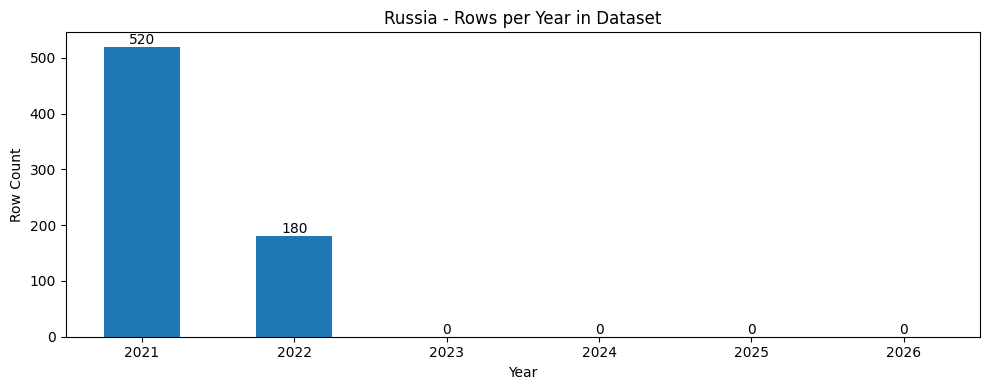

In [37]:
# --- Visual confirming the drop in Russia's number of rows ---
russia_counts = df[df["country_name"] == "Russia"]["week"].dt.year.value_counts()
russia_counts = russia_counts.sort_index()
russia_counts = russia_counts.reindex([2021, 2022, 2023, 2024, 2025, 2026])

ax = russia_counts.plot(kind="bar", figsize=(10, 4))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Russia - Rows per Year in Dataset")
plt.xlabel("Year")
plt.ylabel("Row Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()